# Laboratorio 4 — Extracción lingüística con Hugging Face
## Sentimiento + NER sobre reseñas de **Barça Cafe** (Spotify Camp Nou, Barcelona)

**Curso:** Procesamiento de Lenguaje Natural 


Diego Linares (221256)

Pipeline de NLP con modelos preentrenados de `transformers` que, para un flujo de
36 reseñas en español:

1. clasifica el **sentimiento** de cada reseña (Parte A),
2. extrae **entidades nombradas** (Parte B),
3. integra ambas salidas en una estructura por reseña (Parte C),
4. calcula **estadísticas** y exporta `laboratorio_4_resultados.csv` (Parte D),
5. analiza **casos difíciles** (Parte E) y cierra con la reflexión.

---
## 0. Configuración

In [1]:
# !pip install -q transformers torch pandas
# La celda instala solo lo que falte, así el notebook corre igual en Colab que en local.
import importlib.util
import subprocess
import sys

_faltantes = [p for p in ("transformers", "torch", "pandas", "matplotlib")
              if importlib.util.find_spec(p) is None]
if _faltantes:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *_faltantes])
print("Dependencias listas." if not _faltantes else f"Instalado: {_faltantes}")

Dependencias listas.


In [2]:
from pathlib import Path
import json
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import torch
import transformers
from huggingface_hub.utils import disable_progress_bars
from huggingface_hub.utils import logging as hub_logging
from transformers import pipeline
from transformers.utils import logging as hf_logging

warnings.filterwarnings("ignore")
hf_logging.set_verbosity_error()
hf_logging.disable_progress_bar()
hub_logging.set_verbosity_error()
disable_progress_bars()
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 100)

RAIZ = Path.cwd()
DATOS = RAIZ / "data" / "resenas_barca_cafe.csv"
RESULTADOS = RAIZ / "resultados"
FIGURAS = RESULTADOS / "figuras"
FIGURAS.mkdir(parents=True, exist_ok=True)

DEVICE = 0 if torch.cuda.is_available() else -1
BATCH = 8

print("transformers:", transformers.__version__)
print("torch       :", torch.__version__)
print("dispositivo :", torch.cuda.get_device_name(0) if DEVICE == 0 else "CPU")

transformers: 5.14.1
torch       : 2.10.0+cu128
dispositivo : NVIDIA GeForce RTX 4060 Laptop GPU


---
## 1. Dataset

### 1.1 De dónde salen las reseñas

El restaurante elegido es **Barça Cafe**, el espacio gastronómico oficial del FC Barcelona
junto al Spotify Camp Nou (Carrer d'Arístides Maillol 12, Les Corts, Barcelona). En Google
Maps tiene **3.2 ★ con 424 opiniones** (consultado el 14 de septiembre de 2026), con una
distribución muy polarizada:

jeje barquita siempre!!

| ★ | 5 | 4 | 3 | 2 | 1 |
|---|---:|---:|---:|---:|---:|
| opiniones | 176 | 33 | 34 | 44 | 137 |

Esa polarización lo hace un buen caso de estudio: hay reseñas muy positivas, muy negativas
y bastantes mixtas (buena decoración y ambiente, comida y precios criticados).

### 1.2 Decisión: no copiar las reseñas literales

La guía pide **no incluir datos personales reales**. Una reseña de Google Maps no es solo
texto: viene con nombre del autor, foto, perfil de *Local Guide*, número de reseñas y fecha.
Además el texto pertenece a su autor y los Términos de Servicio de Google Maps no permiten
extraer y reutilizar ese contenido. Por eso el dataset se construyó así:

- **6 reseñas son paráfrasis** de opiniones que Google Maps muestra públicamente
  (los tres fragmentos destacados del resumen y las tres reseñas visibles sin iniciar
  sesión). Se reescribieron con otras palabras, sin autor ni fecha, conservando la opinión
  y el tema (café frío, café caro y baños sucios, vaso de plástico cobrado sin avisar,
  hamburguesa "1/10", camareras amables, comida exquisita).
- **30 reseñas son simuladas** a partir de los **temas reales** que Google Maps detecta en las
  424 opiniones: *hamburguesa* (54 menciones), *barça* (41), *mesa* (18), *cerveza* (16),
  *estadio* (10), *baños* (9), *logo* (8), *vaso de plástico* (7), *refrescos* (6), *taza* (6).
- **Todos los nombres de clientes y empleados son ficticios** (Nuria, Sergi, Santiago, Mateo).
  Se mantienen organizaciones y lugares públicos (FC Barcelona, Real Madrid, Estrella Damm,
  Spotify Camp Nou, Les Corts, Guatemala) y dos referencias públicas del contexto del
  restaurante —el jugador Lamine Yamal y los hermanos Iglesias, a quienes el club anunció como
  responsables de la carta— porque no son datos privados y hacen falta para probar NER con
  personas.

La columna `origen` indica cuál de las dos vías siguió cada reseña.

### 1.3 Etiqueta humana

Antes de correr cualquier modelo se asignó a cada reseña una `etiqueta_humana`
(`POSITIVO`, `NEGATIVO`, `MIXTO`, `NEUTRO`) y una lista de `casos` (negación, sarcasmo,
texto corto, error ortográfico, entidad desconocida, mezcla de idiomas…). Esa etiqueta es la
referencia contra la que se comparan los modelos en las partes D y E.

In [3]:
df_resenas = pd.read_csv(DATOS)
assert len(df_resenas) >= 30, "La guía pide un mínimo de 30 reseñas"

print(f"{len(df_resenas)} reseñas  |  columnas: {list(df_resenas.columns)}\n")
df_resenas[["review_id", "text", "etiqueta_humana", "estrellas", "casos"]]

36 reseñas  |  columnas: ['review_id', 'text', 'etiqueta_humana', 'estrellas', 'casos', 'tema', 'origen']



,review_id,text,etiqueta_humana,estrellas,casos
0,1,"Fuimos después del tour del Museo del FC Barcelona y nos encantó. La decoración azulgrana, las pantallas gigantes y ...",POSITIVO,5,positivo;entidades
1,2,"La camarera Nuria nos atendió de maravilla, súper simpática y rápida. La comida muy rica y el sitio precioso.",POSITIVO,5,positivo;entidades
2,3,Pedí dos cafés y un croissant de chocolate y me lo sirvieron todo frío. Para estar dentro del estadio esperaba basta...,NEGATIVO,1,negativo
3,4,Tres euros y medio por un café mediocre. Encima los baños estaban sucios a mediodía de un martes cualquiera. El FC B...,NEGATIVO,1,negativo;entidades
4,5,"El chico de la caja fue muy amable, eso sí. Lo que me molestó es que te cobran el vaso de plástico sin avisarte ni d...",MIXTO,2,mixto
5,6,Voy probando hamburguesas por todo Barcelona y esta es de las peores: pan seco y carne sin sabor. Un 1 sobre 10.,NEGATIVO,1,negativo;entidades
6,7,"Un sitio precioso para visitar, la comida riquísima y el personal muy atento.",POSITIVO,5,positivo
7,8,Vimos el clásico del Barça contra el Real Madrid en las pantallas gigantes. Ambiente espectacular y la Estrella Damm...,POSITIVO,5,positivo;entidades
8,9,"Genial, 40 minutos esperando una hamburguesa que llegó fría. Una experiencia inolvidable, de verdad.",NEGATIVO,1,sarcasmo
9,10,"No volvería. No es que la comida sea horrible, pero no vale lo que cuesta.",NEGATIVO,2,negacion


In [4]:
cobertura = (df_resenas.assign(caso=df_resenas["casos"].str.split(";"))
             .explode("caso")["caso"].value_counts().rename("reseñas"))

print("Etiqueta humana:")
print(df_resenas["etiqueta_humana"].value_counts().to_string(), "\n")
print("Origen:")
print(df_resenas["origen"].value_counts().to_string(), "\n")
print("Tipos de caso cubiertos:")
print(cobertura.to_string())

Etiqueta humana:
etiqueta_humana
POSITIVO    15
NEGATIVO    14
MIXTO        5
NEUTRO       2 

Origen:
origen
simulada_tema_real           30
parafrasis_resena_visible     6 

Tipos de caso cubiertos:
caso
entidades              14
positivo                9
negativo                7
negacion                6
mixto                   5
texto_corto             4
sarcasmo                3
error_ortografico       2
neutro                  2
mixto_leve              1
entidad_desconocida     1
jerga                   1
mezcla_idiomas          1


---
## Parte A — Análisis de sentimiento

### A.1 Pipeline por defecto

Primero exactamente lo que pide la guía: `pipeline("sentiment-analysis")` sin indicar modelo.
`transformers` elige su modelo por defecto, que conviene imprimir para saber **qué** se está
usando realmente.

In [5]:
sentiment = pipeline("sentiment-analysis", device=DEVICE)

print("modelo    :", sentiment.model.name_or_path)
print("etiquetas :", sentiment.model.config.id2label)

modelo    : distilbert/distilbert-base-uncased-finetuned-sst-2-english
etiquetas : {0: 'NEGATIVE', 1: 'POSITIVE'}


In [6]:
reseñas = df_resenas["text"].tolist()
ids = df_resenas["review_id"].tolist()

resultados = sentiment(reseñas, batch_size=BATCH, truncation=True)

df_sent_defecto = pd.DataFrame({
    "review_id": ids,
    "text": reseñas,
    "label": [r["label"] for r in resultados],
    "score": [round(float(r["score"]), 4) for r in resultados],
})
df_sent_defecto

,review_id,text,label,score
0,1,"Fuimos después del tour del Museo del FC Barcelona y nos encantó. La decoración azulgrana, las pantallas gigantes y ...",POSITIVE,0.9388
1,2,"La camarera Nuria nos atendió de maravilla, súper simpática y rápida. La comida muy rica y el sitio precioso.",NEGATIVE,0.9494
2,3,Pedí dos cafés y un croissant de chocolate y me lo sirvieron todo frío. Para estar dentro del estadio esperaba basta...,NEGATIVE,0.9497
3,4,Tres euros y medio por un café mediocre. Encima los baños estaban sucios a mediodía de un martes cualquiera. El FC B...,NEGATIVE,0.9845
4,5,"El chico de la caja fue muy amable, eso sí. Lo que me molestó es que te cobran el vaso de plástico sin avisarte ni d...",NEGATIVE,0.9827
5,6,Voy probando hamburguesas por todo Barcelona y esta es de las peores: pan seco y carne sin sabor. Un 1 sobre 10.,NEGATIVE,0.9561
6,7,"Un sitio precioso para visitar, la comida riquísima y el personal muy atento.",NEGATIVE,0.5570
7,8,Vimos el clásico del Barça contra el Real Madrid en las pantallas gigantes. Ambiente espectacular y la Estrella Damm...,NEGATIVE,0.6809
8,9,"Genial, 40 minutos esperando una hamburguesa que llegó fría. Una experiencia inolvidable, de verdad.",NEGATIVE,0.6826
9,10,"No volvería. No es que la comida sea horrible, pero no vale lo que cuesta.",NEGATIVE,0.9967


El modelo por defecto es **DistilBERT afinado en SST-2**: un corpus de reseñas de cine
**en inglés**, con solo dos clases. No existe `NEUTRAL`, así que las reseñas mixtas y neutras
quedan forzadas a un polo, y además el vocabulario (`uncased`, inglés) no conoce la mayoría de
las palabras en español. Para tener una comparación justa se repite el análisis con un modelo
entrenado con reseñas en varios idiomas, incluido el español.

### A.2 Modelo multilingüe entrenado con reseñas

`nlptown/bert-base-multilingual-uncased-sentiment` (BERT multilingüe afinado con reseñas de producto en inglés, neerlandés,
alemán, francés, italiano y **español**) devuelve de **1 a 5 estrellas**. Se mapea a tres clases
con la convención habitual de las plataformas de reseñas: 1–2 ★ → `NEGATIVE`, 3 ★ → `NEUTRAL`,
4–5 ★ → `POSITIVE`.

Hay un detalle con el score: con cinco clases la probabilidad se reparte entre estrellas vecinas.
Una reseña claramente positiva puede salir "5 ★ con 0.30" porque otro 0.25 se fue a 4 ★. Por eso
se pide la distribución completa (`top_k=None`) y, además del score de la estrella ganadora,
se guarda `score_polaridad`: la probabilidad **sumada** de todas las estrellas de esa polaridad.

In [7]:
MODELO_SENT_ES = "nlptown/bert-base-multilingual-uncased-sentiment"

sentiment_es = pipeline("sentiment-analysis", model=MODELO_SENT_ES, device=DEVICE)
print("etiquetas :", sentiment_es.model.config.id2label)


def normalizar_sentimiento(etiqueta: str) -> str:
    '''Lleva las etiquetas de cualquier modelo a POSITIVE / NEGATIVE / NEUTRAL.'''
    e = etiqueta.lower()
    if "star" in e:
        n = int(e.split()[0])
        return "NEGATIVE" if n <= 2 else "NEUTRAL" if n == 3 else "POSITIVE"
    if "pos" in e:
        return "POSITIVE"
    if "neg" in e:
        return "NEGATIVE"
    return "NEUTRAL"


def resumir_distribucion(distribucion):
    '''`distribucion` es la salida con top_k=None (todas las clases, ordenadas por score).
    Devuelve (polaridad, etiqueta ganadora, score ganador, score sumado de la polaridad).'''
    top = distribucion[0]
    polaridad = normalizar_sentimiento(top["label"])
    score_polaridad = sum(d["score"] for d in distribucion
                          if normalizar_sentimiento(d["label"]) == polaridad)
    return polaridad, top["label"], float(top["score"]), float(score_polaridad)


resultados_es = sentiment_es(reseñas, batch_size=BATCH, truncation=True, top_k=None)
resumen_es = [resumir_distribucion(d) for d in resultados_es]

df_sent_es = pd.DataFrame({
    "review_id": ids,
    "text": reseñas,
    "label": [r[0] for r in resumen_es],
    "score": [round(r[2], 4) for r in resumen_es],
    "label_original": [r[1] for r in resumen_es],
    "score_polaridad": [round(r[3], 4) for r in resumen_es],
})
df_sent_es

etiquetas : {0: '1 star', 1: '2 stars', 2: '3 stars', 3: '4 stars', 4: '5 stars'}


,review_id,text,label,score,label_original,score_polaridad
0,1,"Fuimos después del tour del Museo del FC Barcelona y nos encantó. La decoración azulgrana, las pantallas gigantes y ...",POSITIVE,0.8571,5 stars,0.9924
1,2,"La camarera Nuria nos atendió de maravilla, súper simpática y rápida. La comida muy rica y el sitio precioso.",POSITIVE,0.8596,5 stars,0.9888
2,3,Pedí dos cafés y un croissant de chocolate y me lo sirvieron todo frío. Para estar dentro del estadio esperaba basta...,NEGATIVE,0.3717,2 stars,0.5224
3,4,Tres euros y medio por un café mediocre. Encima los baños estaban sucios a mediodía de un martes cualquiera. El FC B...,NEGATIVE,0.5659,1 star,0.9039
4,5,"El chico de la caja fue muy amable, eso sí. Lo que me molestó es que te cobran el vaso de plástico sin avisarte ni d...",NEUTRAL,0.4382,3 stars,0.4382
5,6,Voy probando hamburguesas por todo Barcelona y esta es de las peores: pan seco y carne sin sabor. Un 1 sobre 10.,NEGATIVE,0.8476,1 star,0.9630
6,7,"Un sitio precioso para visitar, la comida riquísima y el personal muy atento.",POSITIVE,0.7811,5 stars,0.9814
7,8,Vimos el clásico del Barça contra el Real Madrid en las pantallas gigantes. Ambiente espectacular y la Estrella Damm...,POSITIVE,0.5997,5 stars,0.9230
8,9,"Genial, 40 minutos esperando una hamburguesa que llegó fría. Una experiencia inolvidable, de verdad.",POSITIVE,0.9141,5 stars,0.9833
9,10,"No volvería. No es que la comida sea horrible, pero no vale lo que cuesta.",NEGATIVE,0.4462,1 star,0.8754


### A.3 Comparación rápida entre ambos modelos

In [8]:
MAPA_HUMANO = {"POSITIVO": "POSITIVE", "NEGATIVO": "NEGATIVE", "NEUTRO": "NEUTRAL", "MIXTO": "MIXED"}

comparacion = pd.DataFrame({
    "review_id": ids,
    "humano": df_resenas["etiqueta_humana"].map(MAPA_HUMANO),
    "defecto": df_sent_defecto["label"],
    "score_defecto": df_sent_defecto["score"],
    "multilingue": df_sent_es["label"],
    "estrellas": df_sent_es["label_original"],
    "score_multi": df_sent_es["score"],
    "score_polaridad": df_sent_es["score_polaridad"],
    "text": reseñas,
})
comparacion["acierta_defecto"] = comparacion["humano"] == comparacion["defecto"]
comparacion["acierta_multi"] = comparacion["humano"] == comparacion["multilingue"]

polares = comparacion[comparacion["humano"].isin(["POSITIVE", "NEGATIVE"])]
print(f"Reseñas polares (POS/NEG según humano): {len(polares)}")
print(f"  aciertos modelo por defecto : {polares['acierta_defecto'].sum()} / {len(polares)}")
print(f"  aciertos modelo multilingüe : {polares['acierta_multi'].sum()} / {len(polares)}")
print(f"  ambos modelos coinciden     : {(comparacion['defecto'] == comparacion['multilingue']).sum()} / {len(comparacion)} reseñas")

comparacion.to_csv(RESULTADOS / "a_comparacion_sentimiento.csv", index=False)
comparacion.drop(columns="text")

Reseñas polares (POS/NEG según humano): 29
  aciertos modelo por defecto : 16 / 29
  aciertos modelo multilingüe : 21 / 29
  ambos modelos coinciden     : 20 / 36 reseñas


,review_id,humano,defecto,score_defecto,multilingue,estrellas,score_multi,score_polaridad,acierta_defecto,acierta_multi
0,1,POSITIVE,POSITIVE,0.9388,POSITIVE,5 stars,0.8571,0.9924,True,True
1,2,POSITIVE,NEGATIVE,0.9494,POSITIVE,5 stars,0.8596,0.9888,False,True
2,3,NEGATIVE,NEGATIVE,0.9497,NEGATIVE,2 stars,0.3717,0.5224,True,True
3,4,NEGATIVE,NEGATIVE,0.9845,NEGATIVE,1 star,0.5659,0.9039,True,True
4,5,MIXED,NEGATIVE,0.9827,NEUTRAL,3 stars,0.4382,0.4382,False,False
5,6,NEGATIVE,NEGATIVE,0.9561,NEGATIVE,1 star,0.8476,0.9630,True,True
6,7,POSITIVE,NEGATIVE,0.5570,POSITIVE,5 stars,0.7811,0.9814,False,True
7,8,POSITIVE,NEGATIVE,0.6809,POSITIVE,5 stars,0.5997,0.9230,False,True
8,9,NEGATIVE,NEGATIVE,0.6826,POSITIVE,5 stars,0.9141,0.9833,True,False
9,10,NEGATIVE,NEGATIVE,0.9967,NEGATIVE,1 star,0.4462,0.8754,True,True


---
## Parte B — Reconocimiento de entidades nombradas (NER)

### B.1 Pipeline por defecto

De nuevo primero la llamada literal de la guía. Las etiquetas **dependen del modelo**, así que
se imprime `id2label` en lugar de suponerlas.

In [9]:
ner = pipeline("token-classification", aggregation_strategy="simple", device=DEVICE)

print("modelo    :", ner.model.name_or_path)
print("etiquetas :", sorted(set(ner.model.config.id2label.values())))

modelo    : dbmdz/bert-large-cased-finetuned-conll03-english
etiquetas : ['B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']


In [10]:
def extraer_entidades(ner_pipe, textos, ids):
    '''Una fila por entidad. El texto se toma del span original (start:end), que es más
    fiel que el campo `word` reconstruido por el tokenizador.'''
    filas = []
    for rid, texto, ents in zip(ids, textos, ner_pipe(textos, batch_size=BATCH)):
        for e in ents:
            filas.append({
                "review_id": rid,
                "label": e["entity_group"],
                "text": texto[e["start"]:e["end"]],
                "word_modelo": e["word"],
                "score": round(float(e["score"]), 4),
                "start": e["start"],
                "end": e["end"],
            })
    return pd.DataFrame(filas, columns=["review_id", "label", "text", "word_modelo", "score", "start", "end"])


df_ner_defecto = extraer_entidades(ner, reseñas, ids)
print(f"{len(df_ner_defecto)} entidades en {df_ner_defecto['review_id'].nunique()} reseñas")
print(df_ner_defecto["label"].value_counts().to_string())
df_ner_defecto

46 entidades en 20 reseñas
label
ORG     14
LOC     13
PER     11
MISC     8


,review_id,label,text,word_modelo,score,start,end
0,1,LOC,del,del,0.7241,34,37
1,1,ORG,FC Barcelona,FC Barcelona,0.9869,38,50
2,2,PER,ca,ca,0.3091,3,5
3,2,PER,Nuria,Nuria,0.7685,12,17
4,4,ORG,FC Barcelona,FC Barcelona,0.9991,112,124
5,6,MISC,mb,##mb,0.6611,15,17
6,6,MISC,ues,##ues,0.6291,20,23
7,6,LOC,Barcelona,Barcelona,0.9893,35,44
8,8,ORG,Barça,Barça,0.9954,21,26
9,8,ORG,Real Madrid,Real Madrid,0.9979,37,48


### B.2 Modelo NER en español

`mrm8488/bert-spanish-cased-finetuned-ner` es BETO (BERT entrenado en español) afinado sobre **CoNLL-2002 en español**
(noticias de la agencia EFE) con las clases `PER`, `ORG`, `LOC` y `MISC`. Se corre con la misma
estrategia de agregación que pide la guía, `simple`.

In [11]:
MODELO_NER_ES = "mrm8488/bert-spanish-cased-finetuned-ner"

ner_es = pipeline("token-classification", model=MODELO_NER_ES,
                  aggregation_strategy="simple", device=DEVICE)
print("etiquetas :", sorted(set(ner_es.model.config.id2label.values())))

df_ner_es = extraer_entidades(ner_es, reseñas, ids)
print(f"{len(df_ner_es)} entidades en {df_ner_es['review_id'].nunique()} reseñas")
print(df_ner_es["label"].value_counts().to_string())
df_ner_es

etiquetas : ['B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']
32 entidades en 15 reseñas
label
MISC    11
LOC     11
PER      6
ORG      4


,review_id,label,text,word_modelo,score,start,end
0,1,MISC,Museo del FC Barcelona,Museo del FC Barcelona,0.9461,28,50
1,2,PER,Nu,Nu,0.9966,12,14
2,2,PER,ria,##ria,0.8400,14,17
3,4,ORG,FC Barcelona,FC Barcelona,0.9995,112,124
4,6,LOC,Barcelona,Barcelona,0.9998,35,44
5,8,ORG,Barça,Barça,0.9111,21,26
6,8,ORG,Real Madrid,Real Madrid,0.9996,37,48
7,8,MISC,Estrella Damm,Estrella Damm,0.9992,103,116
8,11,LOC,Les Corts,Les Corts,0.9992,111,120
9,17,LOC,Palau Blaugrana,Palau Blaugrana,0.9990,14,29


### B.3 Problema: entidades partidas en subpalabras

En la tabla anterior aparecen `Nu` + `ria`, `Spo` + `tify Camp Nou`, `Muse` + `u`, `Cul` + `é`.
La causa es la combinación del tokenizador con la estrategia `simple`:

- WordPiece parte las palabras poco frecuentes: `Nuria` → `Nu` `##ria`, `Spotify` → `Spo` `##tif` `##y`.
- El modelo etiqueta **cada subpalabra** por separado. Si a `##ria` le asigna `B-PER` (inicio de
  entidad) en lugar de `I-PER`, `simple` abre una entidad nueva a mitad de palabra.

`aggregation_strategy="first"` agrega a nivel de **palabra**: toda la palabra toma la etiqueta
de su primera subpalabra, así que una palabra no puede quedar partida. Se cuentan los fragmentos
(entidades que empiezan o terminan pegadas a una letra) con ambas estrategias:

In [12]:
def es_fragmento(texto, start, end):
    return (start > 0 and texto[start - 1].isalnum()) or (end < len(texto) and texto[end].isalnum())


def contar_fragmentos(df_ner):
    textos = df_resenas.set_index("review_id")["text"]
    return sum(es_fragmento(textos[r.review_id], r.start, r.end) for r in df_ner.itertuples())


ner_es_first = pipeline("token-classification", model=MODELO_NER_ES,
                        aggregation_strategy="first", device=DEVICE)
df_ner_es_first = extraer_entidades(ner_es_first, reseñas, ids)

print(f"{'estrategia':<32}{'entidades':>10}{'fragmentos':>12}")
for nombre, d in [("defecto inglés, simple", df_ner_defecto),
                  ("español, simple", df_ner_es),
                  ("español, first", df_ner_es_first)]:
    print(f"{nombre:<32}{len(d):>10}{contar_fragmentos(d):>12}")

estrategia                       entidades  fragmentos
defecto inglés, simple                  46          22
español, simple                         32           8
español, first                          27           0


In [13]:
def entidades_por_resena(df_ner):
    return (df_ner.assign(ent=df_ner["label"] + ":" + df_ner["text"])
            .groupby("review_id")["ent"].apply(" | ".join))

ner_lado_a_lado = pd.DataFrame({
    "text": df_resenas.set_index("review_id")["text"],
    "defecto (inglés, simple)": entidades_por_resena(df_ner_defecto),
    "español (simple)": entidades_por_resena(df_ner_es),
    "español (first)": entidades_por_resena(df_ner_es_first),
}).fillna("—")
ner_lado_a_lado = ner_lado_a_lado[(ner_lado_a_lado.iloc[:, 1:] != "—").any(axis=1)]
ner_lado_a_lado.to_csv(RESULTADOS / "b_comparacion_ner.csv")
ner_lado_a_lado

,text,"defecto (inglés, simple)",español (simple),español (first)
review_id,,,,
1,"Fuimos después del tour del Museo del FC Barcelona y nos encantó. La decoración azulgrana, las pantallas gigantes y ...",LOC:del | ORG:FC Barcelona,MISC:Museo del FC Barcelona,MISC:Museo del FC Barcelona
2,"La camarera Nuria nos atendió de maravilla, súper simpática y rápida. La comida muy rica y el sitio precioso.",PER:ca | PER:Nuria,PER:Nu | PER:ria,PER:Nuria
4,Tres euros y medio por un café mediocre. Encima los baños estaban sucios a mediodía de un martes cualquiera. El FC B...,ORG:FC Barcelona,ORG:FC Barcelona,ORG:FC Barcelona
6,Voy probando hamburguesas por todo Barcelona y esta es de las peores: pan seco y carne sin sabor. Un 1 sobre 10.,MISC:mb | MISC:ues | LOC:Barcelona,LOC:Barcelona,LOC:Barcelona
8,Vimos el clásico del Barça contra el Real Madrid en las pantallas gigantes. Ambiente espectacular y la Estrella Damm...,ORG:Barça | ORG:Real Madrid | ORG:Est | PER:rella Damm,ORG:Barça | ORG:Real Madrid | MISC:Estrella Damm,ORG:Barça | ORG:Real Madrid | MISC:Estrella Damm
9,"Genial, 40 minutos esperando una hamburguesa que llegó fría. Una experiencia inolvidable, de verdad.",MISC:mb | MISC:ues,—,—
11,No está nada mal para ser un sitio turístico. Las bravas no tienen nada que envidiar a las de cualquier bar de Les C...,ORG:Les Corts,LOC:Les Corts,LOC:Les Corts
13,Carísimo.,ORG:Carís,—,—
15,"no bale la pena, la amburguesa estava cruda i el refresco sin gas. nunca mas",MISC:ues,—,—


Con `first` desaparecen todos los fragmentos y las entidades quedan legibles (`Nuria`,
`Spotify Camp Nou`, `Museu del Barça`, `Culé`), así que **el flujo integrado usa el modelo en
español con `first`**. Siguen existiendo errores que no son de agregación sino del modelo
(se discuten en la Parte E y en la reflexión): `Lamine Yamal` como `MISC` en vez de `PER`,
`Plaça de Catalunya` reducida a `Catalunya`, o `Ambiente único` marcado como entidad solo por ir
en mayúscula después de un punto.

---
## Parte C — Flujo integrado

Una sola función recibe el lote de reseñas, corre ambos pipelines en batch y devuelve una
estructura por reseña con el formato de la guía. Usa el modelo multilingüe de sentimiento (A.2)
y el NER en español con agregación `first` (B.3). Además de los campos pedidos se añaden
`sentiment_raw` (la estrella) y `polarity_score` (probabilidad sumada de la polaridad).

In [14]:
def analizar_reseñas(textos, ids, sentiment_pipe, ner_pipe, batch_size=BATCH):
    sentimientos = sentiment_pipe(textos, batch_size=batch_size, truncation=True, top_k=None)
    entidades = ner_pipe(textos, batch_size=batch_size)

    salida = []
    for rid, texto, distribucion, ents in zip(ids, textos, sentimientos, entidades):
        polaridad, estrella, score, score_polaridad = resumir_distribucion(distribucion)
        salida.append({
            "review_id": int(rid),
            "text": texto,
            "sentiment": polaridad,
            "sentiment_score": round(score, 4),
            "sentiment_raw": estrella,
            "polarity_score": round(score_polaridad, 4),
            "entities": [
                {"label": e["entity_group"],
                 "text": texto[e["start"]:e["end"]],
                 "score": round(float(e["score"]), 4)}
                for e in ents
            ],
        })
    return salida


flujo = analizar_reseñas(reseñas, ids, sentiment_es, ner_es_first)

with open(RESULTADOS / "laboratorio_4_resultados.json", "w", encoding="utf-8") as f:
    json.dump(flujo, f, ensure_ascii=False, indent=2)

for registro in [flujo[i - 1] for i in (4, 18, 24)]:
    print(json.dumps(registro, ensure_ascii=False, indent=4))

{
    "review_id": 4,
    "text": "Tres euros y medio por un café mediocre. Encima los baños estaban sucios a mediodía de un martes cualquiera. El FC Barcelona debería cuidar más sus instalaciones.",
    "sentiment": "NEGATIVE",
    "sentiment_score": 0.5659,
    "sentiment_raw": "1 star",
    "polarity_score": 0.9039,
    "entities": [
        {
            "label": "ORG",
            "text": "FC Barcelona",
            "score": 0.9995
        }
    ]
}
{
    "review_id": 18,
    "text": "Vinimos desde Guatemala solo para conocer el Spotify Camp Nou y comer aquí fue la guinda. Mi hijo Santiago salió feliz con su camiseta de Lamine Yamal.",
    "sentiment": "POSITIVE",
    "sentiment_score": 0.4784,
    "sentiment_raw": "5 stars",
    "polarity_score": 0.6749,
    "entities": [
        {
            "label": "LOC",
            "text": "Guatemala",
            "score": 0.9996
        },
        {
            "label": "MISC",
            "text": "Spotify Camp Nou",
            "score": 0

---
## Parte D — Estadísticas

Se aplana la estructura integrada en un `DataFrame` (una fila por reseña) y se le añaden la
etiqueta humana y la predicción del modelo por defecto para poder compararlas.

In [15]:
df = pd.DataFrame([{
    "review_id": r["review_id"],
    "text": r["text"],
    "etiqueta_humana": h,
    "casos": c,
    "sentiment": r["sentiment"],
    "sentiment_score": r["sentiment_score"],
    "sentiment_raw": r["sentiment_raw"],
    "polarity_score": r["polarity_score"],
    "sentiment_defecto": d_label,
    "score_defecto": d_score,
    "num_entities": len(r["entities"]),
    "entity_types": ";".join(sorted({e["label"] for e in r["entities"]})),
    "entities": " | ".join(f"{e['label']}:{e['text']} ({e['score']:.2f})" for e in r["entities"]),
} for r, h, c, d_label, d_score in zip(flujo, df_resenas["etiqueta_humana"], df_resenas["casos"],
                                       df_sent_defecto["label"], df_sent_defecto["score"])])

df.to_csv("laboratorio_4_resultados.csv", index=False)
print("Guardado laboratorio_4_resultados.csv —", df.shape)
df.drop(columns=["text", "casos"])

Guardado laboratorio_4_resultados.csv — (36, 13)


,review_id,etiqueta_humana,sentiment,sentiment_score,sentiment_raw,polarity_score,sentiment_defecto,score_defecto,num_entities,entity_types,entities
0,1,POSITIVO,POSITIVE,0.8571,5 stars,0.9924,POSITIVE,0.9388,1,MISC,MISC:Museo del FC Barcelona (0.95)
1,2,POSITIVO,POSITIVE,0.8596,5 stars,0.9888,NEGATIVE,0.9494,1,PER,PER:Nuria (1.00)
2,3,NEGATIVO,NEGATIVE,0.3717,2 stars,0.5224,NEGATIVE,0.9497,0,,
3,4,NEGATIVO,NEGATIVE,0.5659,1 star,0.9039,NEGATIVE,0.9845,1,ORG,ORG:FC Barcelona (1.00)
4,5,MIXTO,NEUTRAL,0.4382,3 stars,0.4382,NEGATIVE,0.9827,0,,
5,6,NEGATIVO,NEGATIVE,0.8476,1 star,0.9630,NEGATIVE,0.9561,1,LOC,LOC:Barcelona (1.00)
6,7,POSITIVO,POSITIVE,0.7811,5 stars,0.9814,NEGATIVE,0.5570,0,,
7,8,POSITIVO,POSITIVE,0.5997,5 stars,0.9230,NEGATIVE,0.6809,3,MISC;ORG,ORG:Barça (0.91) | ORG:Real Madrid (1.00) | MISC:Estrella Damm (1.00)
8,9,NEGATIVO,POSITIVE,0.9141,5 stars,0.9833,NEGATIVE,0.6826,0,,
9,10,NEGATIVO,NEGATIVE,0.4462,1 star,0.8754,NEGATIVE,0.9967,0,,


### D.1 Reseñas por etiqueta y score promedio

In [16]:
por_etiqueta = (df.groupby("sentiment")
                .agg(reseñas=("sentiment_score", "count"), score_promedio=("sentiment_score", "mean"),
                     score_min=("sentiment_score", "min"), score_max=("sentiment_score", "max"),
                     polaridad_promedio=("polarity_score", "mean"))
                .round(4))
por_etiqueta_defecto = (df.groupby("sentiment_defecto")["score_defecto"]
                        .agg(reseñas="count", score_promedio="mean", score_min="min", score_max="max")
                        .round(4))

print("Modelo multilingüe (flujo integrado)")
print(por_etiqueta.to_string())
print(f"\nScore promedio global: {df['sentiment_score'].mean():.4f}   "
      f"(score de polaridad promedio: {df['polarity_score'].mean():.4f})")
print("\nModelo por defecto (inglés, SST-2)")
print(por_etiqueta_defecto.to_string())
print(f"\nScore promedio global: {df['score_defecto'].mean():.4f}")
print("\nDistribución de estrellas predichas:")
print(df["sentiment_raw"].value_counts().sort_index().to_string())

Modelo multilingüe (flujo integrado)
           reseñas  score_promedio  score_min  score_max  polaridad_promedio
sentiment                                                                   
NEGATIVE        13          0.5589     0.3262     0.8619              0.7821
NEUTRAL          7          0.4558     0.4197     0.5005              0.4558
POSITIVE        16          0.6475     0.2972     0.9452              0.8391

Score promedio global: 0.5782   (score de polaridad promedio: 0.7440)

Modelo por defecto (inglés, SST-2)
                   reseñas  score_promedio  score_min  score_max
sentiment_defecto                                               
NEGATIVE                27          0.8633     0.5080     0.9967
POSITIVE                 9          0.8998     0.5527     0.9998

Score promedio global: 0.8724

Distribución de estrellas predichas:
sentiment_raw
1 star      8
2 stars     5
3 stars     7
4 stars     1
5 stars    15


### D.2 Las cinco reseñas de menor confianza

In [17]:
menor_confianza = df.nsmallest(5, "sentiment_score")[
    ["review_id", "text", "etiqueta_humana", "sentiment", "sentiment_raw", "sentiment_score", "polarity_score"]]
menor_confianza_defecto = df.nsmallest(5, "score_defecto")[
    ["review_id", "text", "etiqueta_humana", "sentiment_defecto", "score_defecto"]]

print("Multilingüe:")
display(menor_confianza)
print("Por defecto:")
display(menor_confianza_defecto)

Multilingüe:


,review_id,text,etiqueta_humana,sentiment,sentiment_raw,sentiment_score,polarity_score
23,24,"Celebramos el cumpleaños de mi sobrino Mateo aquí y el equipo del Barça Cafe se portó genial, hasta le pusieron una ...",POSITIVO,POSITIVE,5 stars,0.2972,0.5515
16,17,"Está junto al Palau Blaugrana, en la calle Arístides Maillol. Abren a las 10 de la mañana.",NEUTRO,POSITIVE,5 stars,0.3230,0.5834
12,13,Carísimo.,NEGATIVO,POSITIVE,5 stars,0.3235,0.5436
28,29,"La Blaugrana Burger con salsa Culé está brutal, pídanla sin dudar.",POSITIVO,NEGATIVE,1 star,0.3262,0.5766
2,3,Pedí dos cafés y un croissant de chocolate y me lo sirvieron todo frío. Para estar dentro del estadio esperaba basta...,NEGATIVO,NEGATIVE,2 stars,0.3717,0.5224


Por defecto:


,review_id,text,etiqueta_humana,sentiment_defecto,score_defecto
25,26,Meh.,NEGATIVO,NEGATIVE,0.5080
33,34,"Cinco estrellas... para el aire acondicionado, que es lo único que funcionaba.",NEGATIVO,POSITIVE,0.5527
6,7,"Un sitio precioso para visitar, la comida riquísima y el personal muy atento.",POSITIVO,NEGATIVE,0.5570
16,17,"Está junto al Palau Blaugrana, en la calle Arístides Maillol. Abren a las 10 de la mañana.",NEUTRO,NEGATIVE,0.5702
13,14,"La decoración con camisetas firmadas y lámparas en forma de balón es preciosa, pero la comida es muy normalita y cara.",MIXTO,NEGATIVE,0.6372


### D.3 Entidades

In [18]:
df_entidades = pd.DataFrame([
    {"review_id": r["review_id"], **e} for r in flujo for e in r["entities"]
])
df_entidades.to_csv(RESULTADOS / "d_entidades.csv", index=False)

print("NER en español con agregación first (flujo integrado)")
print(f"Entidades totales               : {len(df_entidades)}   (con 'simple' eran {len(df_ner_es)})")
print(f"Promedio de entidades por reseña: {df['num_entities'].mean():.2f}")
print(f"Reseñas con al menos una entidad: {(df['num_entities'] > 0).sum()} / {len(df)}")
print(f"Tipos de entidad encontrados    : {sorted(df_entidades['label'].unique())}\n")

tipos = (df_entidades.groupby("label")
         .agg(entidades=("text", "count"), score_promedio=("score", "mean"),
              ejemplos=("text", lambda s: ", ".join(dict.fromkeys(s))))
         .round(4).sort_values("entidades", ascending=False))
tipos

NER en español con agregación first (flujo integrado)
Entidades totales               : 27   (con 'simple' eran 32)
Promedio de entidades por reseña: 0.75
Reseñas con al menos una entidad: 15 / 36
Tipos de entidad encontrados    : ['LOC', 'MISC', 'ORG', 'PER']



,entidades,score_promedio,ejemplos
label,,,
LOC,10,0.9946,"Barcelona, Les Corts, Palau Blaugrana, calle Arístides Maillol, Guatemala, Catalunya, México, Japón, Brasil"
MISC,8,0.8866,"Museo del FC Barcelona, Estrella Damm, Spotify Camp Nou, Lamine Yamal, Museu del Barça, Blaugrana Burger, Culé, Ambi..."
PER,5,0.9359,"Nuria, Santiago, Iglesias, Mateo, Sergi"
ORG,4,0.9774,"FC Barcelona, Barça, Real Madrid, Barça Cafe"


### D.4 Precisión, recall y F1 contra la etiqueta humana

Con la etiqueta humana del dataset se puede ir más allá del score. Se evalúan las reseñas
**polares** (humano = POSITIVO o NEGATIVO); una predicción `NEUTRAL` sobre una reseña polar
cuenta como error. Con 29 reseñas las cifras son orientativas, no una evaluación formal.

In [19]:
from sklearn.metrics import classification_report, confusion_matrix

pol = df[df["etiqueta_humana"].isin(["POSITIVO", "NEGATIVO"])]
y_true = pol["etiqueta_humana"].map(MAPA_HUMANO)
metricas = []
for nombre, columna in [("defecto (SST-2 inglés)", "sentiment_defecto"), ("multilingüe (estrellas)", "sentiment")]:
    print(f"=== {nombre} ===")
    print(classification_report(y_true, pol[columna], labels=["POSITIVE", "NEGATIVE"], zero_division=0, digits=3))
    rep = classification_report(y_true, pol[columna], labels=["POSITIVE", "NEGATIVE"], zero_division=0, output_dict=True)
    metricas.append({"modelo": nombre, "accuracy": round((y_true == pol[columna]).mean(), 3),
                     **{f"{k}_{m}": round(rep[k][m], 3) for k in ("POSITIVE", "NEGATIVE") for m in ("precision", "recall", "f1-score")}})

etiquetas = ["POSITIVE", "NEUTRAL", "NEGATIVE"]
print("Matriz de confusión del multilingüe (filas = humano, columnas = modelo):")
print(pd.DataFrame(confusion_matrix(y_true, pol["sentiment"], labels=etiquetas), index=etiquetas, columns=etiquetas))

print("\n¿A dónde van las reseñas MIXTAS y NEUTRAS?")
print(df[df["etiqueta_humana"].isin(["MIXTO", "NEUTRO"])][
    ["review_id", "etiqueta_humana", "sentiment_raw", "sentiment_score", "sentiment_defecto", "score_defecto"]].to_string(index=False))

df_metricas = pd.DataFrame(metricas)
df_metricas

=== defecto (SST-2 inglés) ===
              precision    recall  f1-score   support

    POSITIVE      0.625     0.333     0.435        15
    NEGATIVE      0.524     0.786     0.629        14

    accuracy                          0.552        29
   macro avg      0.574     0.560     0.532        29
weighted avg      0.576     0.552     0.528        29

=== multilingüe (estrellas) ===
              precision    recall  f1-score   support

    POSITIVE      0.800     0.800     0.800        15
    NEGATIVE      0.818     0.643     0.720        14

   micro avg      0.808     0.724     0.764        29
   macro avg      0.809     0.721     0.760        29
weighted avg      0.809     0.724     0.761        29

Matriz de confusión del multilingüe (filas = humano, columnas = modelo):
          POSITIVE  NEUTRAL  NEGATIVE
POSITIVE        12        1         2
NEUTRAL          0        0         0
NEGATIVE         3        2         9

¿A dónde van las reseñas MIXTAS y NEUTRAS?
 review_id eti

,modelo,accuracy,POSITIVE_precision,POSITIVE_recall,POSITIVE_f1-score,NEGATIVE_precision,NEGATIVE_recall,NEGATIVE_f1-score
0,defecto (SST-2 inglés),0.552,0.625,0.333,0.435,0.524,0.786,0.629
1,multilingüe (estrellas),0.724,0.800,0.800,0.800,0.818,0.643,0.720


### D.5 ¿Un score alto significa acierto?

Se agrupan las reseñas polares por rango de score y se mide el porcentaje de aciertos en cada
rango. Si el score estuviera bien calibrado, el acierto debería subir con el score.

In [20]:
rangos = [0, 0.5, 0.8, 1.0]
filas = []
for nombre, pred, score in [("defecto", "sentiment_defecto", "score_defecto"),
                            ("multilingüe (estrella)", "sentiment", "sentiment_score"),
                            ("multilingüe (polaridad)", "sentiment", "polarity_score")]:
    tmp = pol.assign(acierto=pol[pred] == y_true, rango=pd.cut(pol[score], rangos))
    for rango, g in tmp.groupby("rango", observed=False):
        filas.append({"modelo": nombre, "rango_score": str(rango), "reseñas": len(g),
                      "aciertos": int(g["acierto"].sum()),
                      "tasa_acierto": round(g["acierto"].mean(), 3) if len(g) else None})
calibracion = pd.DataFrame(filas)
calibracion.to_csv(RESULTADOS / "d_calibracion_score.csv", index=False)
display(calibracion)

print("Las 3 predicciones con mayor score del modelo multilingüe:")
df.nlargest(3, "sentiment_score")[["review_id", "text", "etiqueta_humana", "sentiment", "sentiment_score"]]

,modelo,rango_score,reseñas,aciertos,tasa_acierto
0,defecto,"(0.0, 0.5]",0,0,NaN
1,defecto,"(0.5, 0.8]",6,2,0.333
2,defecto,"(0.8, 1.0]",23,14,0.609
3,multilingüe (estrella),"(0.0, 0.5]",12,7,0.583
4,multilingüe (estrella),"(0.5, 0.8]",9,8,0.889
5,multilingüe (estrella),"(0.8, 1.0]",8,6,0.750
6,multilingüe (polaridad),"(0.0, 0.5]",3,0,0.000
7,multilingüe (polaridad),"(0.5, 0.8]",9,7,0.778
8,multilingüe (polaridad),"(0.8, 1.0]",17,14,0.824


Las 3 predicciones con mayor score del modelo multilingüe:


,review_id,text,etiqueta_humana,sentiment,sentiment_score
33,34,"Cinco estrellas... para el aire acondicionado, que es lo único que funcionaba.",NEGATIVO,POSITIVE,0.9452
8,9,"Genial, 40 minutos esperando una hamburguesa que llegó fría. Una experiencia inolvidable, de verdad.",NEGATIVO,POSITIVE,0.9141
24,25,"Personal desbordado, música altísima y nadie limpió nuestra mesa en toda la tarde. Una pena para la imagen del club.",NEGATIVO,NEGATIVE,0.8619


In [21]:
resumen = pd.DataFrame([
    ("reseñas", len(df)),
    ("positivas (multilingüe)", int((df["sentiment"] == "POSITIVE").sum())),
    ("negativas (multilingüe)", int((df["sentiment"] == "NEGATIVE").sum())),
    ("neutras (multilingüe)", int((df["sentiment"] == "NEUTRAL").sum())),
    ("score promedio (multilingüe)", round(df["sentiment_score"].mean(), 4)),
    ("positivas (defecto)", int((df["sentiment_defecto"] == "POSITIVE").sum())),
    ("negativas (defecto)", int((df["sentiment_defecto"] == "NEGATIVE").sum())),
    ("score promedio (defecto)", round(df["score_defecto"].mean(), 4)),
    ("accuracy polares (defecto)", df_metricas.loc[0, "accuracy"]),
    ("accuracy polares (multilingüe)", df_metricas.loc[1, "accuracy"]),
    ("entidades totales", len(df_entidades)),
    ("entidades promedio por reseña", round(df["num_entities"].mean(), 2)),
    ("tipos de entidad", ";".join(sorted(df_entidades["label"].unique()))),
], columns=["metrica", "valor"])
resumen.to_csv(RESULTADOS / "d_resumen_estadisticas.csv", index=False)
df_metricas.to_csv(RESULTADOS / "d_metricas_sentimiento.csv", index=False)
resumen

,metrica,valor
0,reseñas,36
1,positivas (multilingüe),16
2,negativas (multilingüe),13
3,neutras (multilingüe),7
4,score promedio (multilingüe),0.5782
5,positivas (defecto),9
6,negativas (defecto),27
7,score promedio (defecto),0.8724
8,accuracy polares (defecto),0.552
9,accuracy polares (multilingüe),0.724


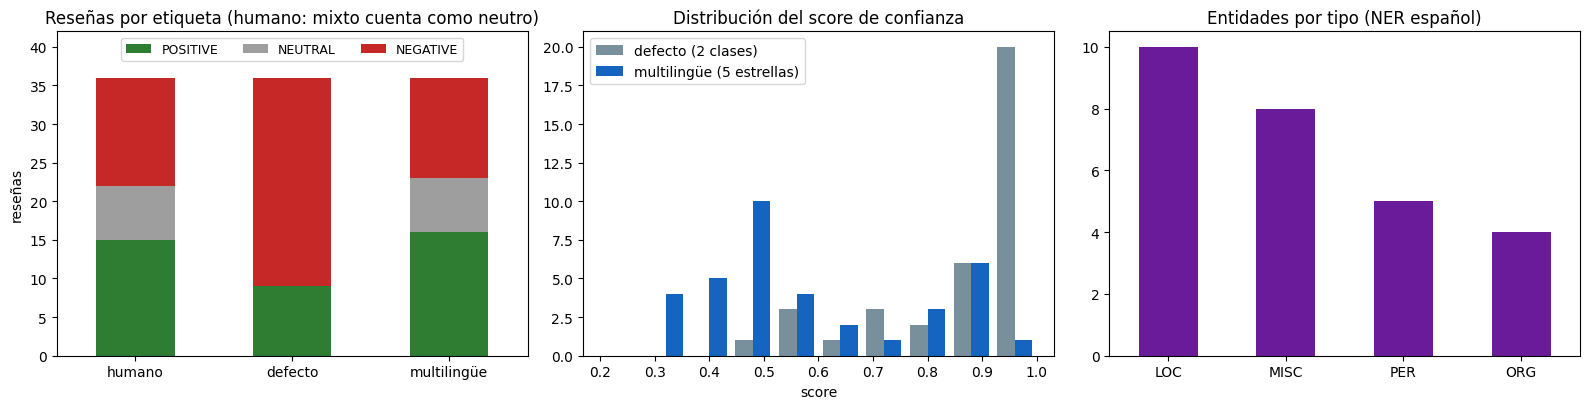

In [22]:
fig, ejes = plt.subplots(1, 3, figsize=(16, 4.2))
orden = ["POSITIVE", "NEUTRAL", "NEGATIVE"]
colores = {"POSITIVE": "#2e7d32", "NEUTRAL": "#9e9e9e", "NEGATIVE": "#c62828"}

conteo = pd.DataFrame({
    "humano": df["etiqueta_humana"].map(MAPA_HUMANO).replace({"MIXED": "NEUTRAL"}).value_counts(),
    "defecto": df["sentiment_defecto"].value_counts(),
    "multilingüe": df["sentiment"].value_counts(),
}).reindex(orden).fillna(0)
conteo.T.plot(kind="bar", stacked=True, color=[colores[c] for c in orden], ax=ejes[0], rot=0)
ejes[0].set_title("Reseñas por etiqueta (humano: mixto cuenta como neutro)")
ejes[0].legend(ncol=3, loc="upper center", fontsize=9)
ejes[0].set_ylim(0, 42)
ejes[0].set_ylabel("reseñas")

ejes[1].hist([df["score_defecto"], df["sentiment_score"]], bins=10, range=(0.2, 1),
             label=["defecto (2 clases)", "multilingüe (5 estrellas)"], color=["#78909c", "#1565c0"])
ejes[1].set_title("Distribución del score de confianza")
ejes[1].set_xlabel("score")
ejes[1].legend()

tipos["entidades"].plot(kind="bar", ax=ejes[2], color="#6a1b9a", rot=0)
ejes[2].set_title("Entidades por tipo (NER español)")
ejes[2].set_xlabel("")

plt.tight_layout()
plt.savefig(FIGURAS / "d_resumen.png", dpi=130, bbox_inches="tight")
plt.show()

---
## Parte E — Análisis de casos difíciles

Se eligieron **ocho** reseñas que cubren los tipos de dificultad de la guía. Para cada una se
muestra la predicción de ambos modelos, la interpretación humana, si coinciden y la posible
causa del error. La columna *coincide* se calcula contra el flujo integrado (multilingüe);
para una reseña mixta se considera acierto `NEUTRAL` (3 ★).

In [23]:
import textwrap

CASOS_DIFICILES = {
    # review_id: (tipo de dificultad, interpretación humana, posible causa del error)
    9: ("Sarcasmo",
        "NEGATIVO. Queja por 40 minutos de espera y comida fría; 'genial' e 'inolvidable' son ironía.",
        "Pesan las palabras positivas ('Genial', 'inolvidable') y el modelo no detecta que chocan con "
        "los hechos narrados (40 minutos, llegó fría). Reconocer ironía exige razonamiento pragmático "
        "que un clasificador entrenado con reseñas literales no aprende."),
    34: ("Sarcasmo con ancla léxica",
         "NEGATIVO. Las 'cinco estrellas' son para el aire acondicionado, lo único que funcionaba.",
         "'Cinco estrellas' es casi literalmente la etiqueta '5 stars' con la que se entrenó; en reseñas "
         "reales esa frase casi siempre acompaña a una nota de 5. Lo más probable es que el modelo haya "
         "aprendido ese atajo y no procese el giro '...para el aire acondicionado'."),
    27: ("Doble negación",
         "POSITIVO. 'No puedo decir que no me haya gustado' equivale a 'me gustó'; 'no tardaron nada' es un elogio.",
         "Tres marcadores negativos ('no', 'no', 'nada') que el modelo parece sumar como señales negativas "
         "en lugar de componerlos: dos negaciones se cancelan y 'no tardaron nada' es positivo."),
    11: ("Negación con sentido positivo (litote)",
         "POSITIVO. 'No está nada mal' y 'no tienen nada que envidiar' son elogios.",
         "Acumula 'no', 'nada', 'mal' y 'envidiar'. El modelo duda (3 estrellas) y no llega a invertir la "
         "polaridad: sumando 4 y 5 estrellas la probabilidad positiva es 0.48, apenas por encima del 0.45 neutro."),
    23: ("Opinión mixta",
         "MIXTO. Servicio excelente ('un amor') y cocina muy mala ('un desastre').",
         "Una sola etiqueta no puede expresar dos aspectos opuestos. El modelo pesa más la cláusula que "
         "sigue al 'pero' y da 2 estrellas; el score bajo refleja la mezcla. Haría falta análisis de "
         "sentimiento por aspectos (servicio / comida / precio)."),
    13: ("Texto muy corto",
         "NEGATIVO. Una sola palabra que critica el precio.",
         "Sin contexto, y con un vocabulario multilingüe que trocea la palabra en 'car' + '##isi' + '##mo', "
         "el modelo no tiene señal. Su score es de los más bajos del lote: avisa que no sabe. El modelo por "
         "defecto, en cambio, se equivoca con 0.985."),
    29: ("Entidad desconocida + jerga",
         "POSITIVO. En España 'brutal' significa 'buenísimo'; 'Blaugrana Burger' y 'salsa Culé' son productos.",
         "El sentido normativo de 'brutal' (cruel, violento), que coincide con el inglés, es negativo y "
         "probablemente es el que dominó en el entrenamiento. Los nombres inventados no aportan señal. En NER, "
         "con 'simple' 'Culé' salía partido en 'Cul' + 'é'; con 'first' ambos productos quedan como MISC."),
    16: ("Errores ortográficos",
         "POSITIVO. Elogio claro pese a 'q', 'buenisimos' y 'bolveremos'.",
         "Coincide. Las faltas no borran las señales fuertes ('buen sitio', 'super atento', '!!') y el modelo "
         "es uncased y quita acentos, así que 'buenisimos' y 'buenísimos' se tokenizan igual. El modelo por "
         "defecto falla porque no conoce el español."),
    28: ("Negatividad implícita + NER",
         "NEGATIVO. Compara el local con un bar de aeropuerto con precios de zona turística.",
         "No hay palabras negativas: la crítica está en la comparación, y entenderla requiere saber que un "
         "'bar de aeropuerto' es caro y mediocre. El modelo queda en 3 estrellas. En NER, 'Plaça de Catalunya' "
         "se reduce a 'Catalunya' y con 'simple' 'Museu' salía partido en 'Muse' + 'u'."),
}


def coincidencia(humano, modelo):
    h = MAPA_HUMANO[humano]
    if h == modelo or (h == "MIXED" and modelo == "NEUTRAL"):
        return "Sí"
    if h == "MIXED" or "NEUTRAL" in (h, modelo):
        return "Parcial"
    return "No"


por_id = df.set_index("review_id")
filas = []
for rid, (tipo, humano, causa) in CASOS_DIFICILES.items():
    r = por_id.loc[rid]
    filas.append({
        "review_id": rid,
        "tipo": tipo,
        "text": r["text"],
        "prediccion": f"{r['sentiment']} ({r['sentiment_raw']}, {r['sentiment_score']:.3f})",
        "score_polaridad": r["polarity_score"],
        "prediccion_defecto": f"{r['sentiment_defecto']} ({r['score_defecto']:.3f})",
        "entidades": r["entities"] or "—",
        "interpretacion_humana": humano,
        "coincide": coincidencia(r["etiqueta_humana"], r["sentiment"]),
        "coincide_defecto": coincidencia(r["etiqueta_humana"], r["sentiment_defecto"]),
        "posible_causa": causa,
    })

casos = pd.DataFrame(filas)
casos.to_csv(RESULTADOS / "e_casos_dificiles.csv", index=False)

print("Coincidencia con la interpretación humana")
print("  multilingüe:", casos["coincide"].value_counts().to_dict())
print("  defecto    :", casos["coincide_defecto"].value_counts().to_dict())
casos[["review_id", "tipo", "text", "prediccion", "score_polaridad", "prediccion_defecto", "coincide", "coincide_defecto"]]

Coincidencia con la interpretación humana
  multilingüe: {'No': 5, 'Parcial': 3, 'Sí': 1}
  defecto    : {'No': 7, 'Sí': 1, 'Parcial': 1}


,review_id,tipo,text,prediccion,score_polaridad,prediccion_defecto,coincide,coincide_defecto
0,9,Sarcasmo,"Genial, 40 minutos esperando una hamburguesa que llegó fría. Una experiencia inolvidable, de verdad.","POSITIVE (5 stars, 0.914)",0.9833,NEGATIVE (0.683),No,Sí
1,34,Sarcasmo con ancla léxica,"Cinco estrellas... para el aire acondicionado, que es lo único que funcionaba.","POSITIVE (5 stars, 0.945)",0.9735,POSITIVE (0.553),No,No
2,27,Doble negación,No puedo decir que no me haya gustado: el bocadillo de jamón estaba bueno y no tardaron nada.,"NEGATIVE (2 stars, 0.559)",0.8195,NEGATIVE (0.977),No,No
3,11,Negación con sentido positivo (litote),No está nada mal para ser un sitio turístico. Las bravas no tienen nada que envidiar a las de cualquier bar de Les C...,"NEUTRAL (3 stars, 0.446)",0.4460,NEGATIVE (0.995),Parcial,No
4,23,Opinión mixta,"Los camareros son un amor, pero la cocina es un desastre: el pollo seco y las patatas congeladas.","NEGATIVE (2 stars, 0.433)",0.6529,NEGATIVE (0.973),Parcial,Parcial
5,13,Texto muy corto,Carísimo.,"POSITIVE (5 stars, 0.324)",0.5436,POSITIVE (0.985),No,No
6,29,Entidad desconocida + jerga,"La Blaugrana Burger con salsa Culé está brutal, pídanla sin dudar.","NEGATIVE (1 star, 0.326)",0.5766,NEGATIVE (0.984),No,No
7,16,Errores ortográficos,"q buen sitio!! los nachos buenisimos y el camarero super atento, bolveremos seguro","POSITIVE (5 stars, 0.738)",0.9655,NEGATIVE (0.754),Sí,No
8,28,Negatividad implícita + NER,Esperaba algo digno del Museu del Barça y me encontré un bar de aeropuerto con precios de Plaça de Catalunya.,"NEUTRAL (3 stars, 0.460)",0.4597,POSITIVE (0.879),Parcial,No


In [24]:
for c in filas:
    print(f"#{c['review_id']} · {c['tipo'].upper()}")
    print(textwrap.fill(c["text"], 105, initial_indent="  Texto      : ", subsequent_indent=" " * 15))
    print(f"  Modelo     : {c['prediccion']}  ·  polaridad {c['score_polaridad']:.3f}  ·  defecto {c['prediccion_defecto']}")
    print(f"  Entidades  : {c['entidades']}")
    print(textwrap.fill(c["interpretacion_humana"], 105, initial_indent="  Humano     : ", subsequent_indent=" " * 15))
    print(f"  ¿Coincide? : {c['coincide']}")
    print(textwrap.fill(c["posible_causa"], 105, initial_indent="  Causa      : ", subsequent_indent=" " * 15))
    print()

#9 · SARCASMO
  Texto      : Genial, 40 minutos esperando una hamburguesa que llegó fría. Una experiencia inolvidable,
               de verdad.
  Modelo     : POSITIVE (5 stars, 0.914)  ·  polaridad 0.983  ·  defecto NEGATIVE (0.683)
  Entidades  : —
  Humano     : NEGATIVO. Queja por 40 minutos de espera y comida fría; 'genial' e 'inolvidable' son
               ironía.
  ¿Coincide? : No
  Causa      : Pesan las palabras positivas ('Genial', 'inolvidable') y el modelo no detecta que chocan
               con los hechos narrados (40 minutos, llegó fría). Reconocer ironía exige razonamiento
               pragmático que un clasificador entrenado con reseñas literales no aprende.

#34 · SARCASMO CON ANCLA LÉXICA
  Texto      : Cinco estrellas... para el aire acondicionado, que es lo único que funcionaba.
  Modelo     : POSITIVE (5 stars, 0.945)  ·  polaridad 0.974  ·  defecto POSITIVE (0.553)
  Entidades  : —
  Humano     : NEGATIVO. Las 'cinco estrellas' son para el aire acondicionado,

### Patrones que dejan los casos difíciles

1. **El score no protege contra el sarcasmo.** Las dos predicciones con mayor score de todo el
   lote (#34 con 0.945 y #9 con 0.914) son sarcasmos clasificados como 5 estrellas. El modelo está
   más seguro justo cuando más se equivoca.
2. **La negación se lee como vocabulario, no como operador.** "No está nada mal" (#11) y
   "no puedo decir que no me haya gustado" (#27) contienen varias palabras negativas y el modelo las
   acumula en vez de invertir su efecto. El modelo por defecto falla las dos con scores de 0.99 y 0.98.
3. **Cuando falta señal, el modelo sí lo avisa.** En el texto de una palabra (#13), en la reseña
   informativa (#17) y en la crítica implícita (#28) el score cae por debajo de 0.5. En esos casos el
   score funciona como alarma útil.
4. **Robusto a faltas, frágil ante la jerga.** Las reseñas con errores ortográficos (#15 y #16) se
   clasifican bien, pero una sola palabra de uso regional ("brutal", #29) invierte la predicción.
5. **En NER hay dos tipos de error.** Los de *agregación* (entidades partidas en subpalabras)
   desaparecen con `first`. Los de *etiquetado* se quedan: una persona pública marcada como `MISC`,
   una entidad truncada y un falso positivo por mayúscula inicial.

---
## Preguntas de reflexión

### 1. ¿El modelo parece apropiado para reseñas en español?

**El modelo por defecto, no.** `distilbert-base-uncased-finetuned-sst-2-english` se entrenó con
reseñas de cine en inglés. Sobre las 36 reseñas predijo `NEGATIVE` en 27, acertó el **55 %** de
las polares (apenas mejor que una moneda) y solo reconoció **1 de cada 3** positivas (recall 0.33).
Sus predicciones positivas más seguras son justo las dos reseñas con palabras en inglés ("Top!!" y
"Amazing… very friendly", ambas con 0.9998).
Lo más problemático es que falla con seguridad: su score promedio es 0.87.

**El modelo multilingüe es aceptable como primer filtro, pero no es ideal.**
`nlptown/bert-base-multilingual-uncased-sentiment` sí vio reseñas en español y llega al **72 %** de
acierto, con F1 de 0.80 en positivas y 0.72 en negativas. Aun así se entrenó con reseñas de
*producto*, no de restaurantes, y no conoce la jerga de España. El siguiente paso sería un modelo
nativo en español (en una prueba exploratoria con seis frases,
`pysentimiento/robertuito-sentiment-analysis` resolvió mejor "no está mal" pero también cayó en
el sarcasmo) o, mejor, afinar con unos cientos de reseñas de restaurantes etiquetadas.

### 2. ¿Qué errores de sentimiento encontraste?

- **Sarcasmo** clasificado como positivo y con el score más alto del lote (#9, #34).
- **Negación compuesta:** litote (#11 → 3 ★) y doble negación (#27 → 2 ★).
- **Jerga regional:** "está brutal" leído como negativo (#29 → 1 ★).
- **Texto muy corto:** "Carísimo." → 5 ★ (#13), aunque con score bajo.
- **Reseña informativa** sin opinión (#17) → 5 ★. El modelo no tiene clase "sin opinión": todas las
  reseñas con las que se entrenó valoran algo.
- **Crítica implícita** por comparación (#28 → 3 ★).
- **Mixtas:** tres de cinco caen en 3 ★ y dos en 2 ★. Es razonable, pero pierde el aspecto positivo.
- **Sesgo del modelo por defecto:** casi todo lo que no entiende lo manda a `NEGATIVE`, y así acierta
  negativas "por accidente".

### 3. ¿Qué problemas observaste en NER?

- **Fragmentación en subpalabras** con `aggregation_strategy="simple"`: 8 fragmentos de 32 entidades
  en el modelo en español (`Nu`+`ria`, `Spo`+`tify Camp Nou`) y 22 de 46 en el modelo por defecto.
  Con `first` bajan a 0.
- **Falsos positivos del modelo en inglés** sobre palabras en mayúscula o trozos de palabras:
  `del` → LOC, `ca` → PER, `Me` (de "Meh.") → PER, `Carís` → ORG, y `mb`/`ues` → MISC dentro de
  "hamburguesa(s)" (posiblemente por su parecido con *Hamburg*).
- **Tipo equivocado:** `Lamine Yamal` sale como `MISC` y no como `PER`.
- **Entidades truncadas:** `Plaça de Catalunya` → `Catalunya`; de "los hermanos Iglesias" solo queda
  `Iglesias`, que además es un sustantivo común.
- **Mayúscula = entidad:** `Ambiente único` se marca `MISC` solo por empezar oración.
- **Categorías que no encajan en el dominio:** CoNLL-2002 son noticias. No existe una clase para
  platos o productos (`Blaugrana Burger` cae en `MISC`), y `Spotify Camp Nou` es a la vez estadio
  (LOC) y marca patrocinada (ORG), así que el modelo lo manda a `MISC`.
- **Lo que funcionó:** los cuatro nombres ficticios de personas (Nuria, Santiago, Mateo, Sergi) y las
  organizaciones y países se detectaron, todos con score superior a 0.9.

### 4. ¿Cómo influye el score en tu confianza?

El score es la probabilidad softmax de la clase ganadora, **no la probabilidad de acertar**.

- En el modelo por defecto, de las 23 predicciones polares con score > 0.8 solo acertó el **61 %**.
- En el multilingüe, el rango de score > 0.8 acierta menos (75 %) que el de 0.5–0.8 (89 %), porque
  ahí están los dos sarcasmos.
- Con cinco clases el score de la estrella ganadora **subestima** la confianza: #24 es claramente
  positiva, acierta y tiene 0.30, porque el resto de la probabilidad se fue a 4 estrellas. Sumando la
  polaridad sube a 0.55. Ese `score_polaridad` se comporta mejor: 82 % de acierto por encima de 0.8
  y 0 % por debajo de 0.5 (aunque ese rango solo tiene 3 reseñas).

Conclusión: **un score bajo es una buena alarma** para mandar la reseña a revisión humana, pero **un
score alto no es garantía**. Además no es comparable entre modelos con distinto número de clases, y
saber si está calibrado exige datos etiquetados.

### 5. ¿Qué datos etiquetarías manualmente para calcular precision, recall y F1?

**Sentimiento**
- Una muestra **estratificada** de reseñas reales: todas las estrellas, idiomas y longitudes, y
  sobremuestreo de los casos difíciles (sarcasmo, negación, mixtas), porque son raros pero caros.
- Al menos 200–300 reseñas, para tener unas 30 por clase aun con la distribución real, que es muy
  polarizada (176 / 33 / 34 / 44 / 137).
- Etiquetas `POSITIVO` / `NEGATIVO` / `NEUTRO` / `MIXTO` y marcas de fenómeno, asignadas por **dos
  anotadores** con una guía escrita, midiendo su acuerdo (kappa de Cohen). Las estrellas del usuario
  sirven como señal débil, pero no reemplazan la etiqueta: la nota y el texto no siempre coinciden.
- Reportar **F1 macro**, porque las clases están desbalanceadas.

En este laboratorio ya se hizo una versión mínima: la columna `etiqueta_humana` permitió calcular
las métricas de la Parte D.4.

**NER**
- Spans exactos con su tipo, siguiendo una guía que decida de antemano los casos ambiguos: estadio =
  LOC, Barça Cafe = ORG, platos = una clase `PRODUCTO` nueva y figuras públicas = PER.
- Evaluación **a nivel de entidad** (coincidencia exacta de span y tipo, como `seqeval`), y aparte
  las coincidencias parciales para cuantificar las truncaciones (`Catalunya` vs. `Plaça de Catalunya`).

### 6. ¿Usarías estas predicciones para tomar decisiones automáticas importantes? ¿Por qué?

**No.**
- El 72 % de acierto sale de 29 reseñas: la muestra es pequeña y el margen de error, amplio.
- Los errores **no son aleatorios**: se concentran en sarcasmo y negación, que abundan justo en las
  reseñas enojadas, las que más importan.
- Los errores más graves llegan con score alto, así que un umbral de confianza no los filtra.
- El NER extrae nombres de empleados ("el encargado Sergi"). Tomar decisiones sobre personas a
  partir de eso tiene implicaciones laborales y de privacidad.

Sí lo usaría como **apoyo**, con una persona en el circuito:
- **Tendencias agregadas**, por ejemplo el porcentaje de reseñas negativas por mes o por tema. Ahí
  los errores individuales se compensan y basta con una auditoría humana periódica.
- **Triaje:** mandar a revisión humana primero lo `NEGATIVE` o con score de polaridad bajo.

No lo usaría para responder públicamente de forma automática, borrar reseñas, fijar precios ni
evaluar o sancionar a un empleado mencionado.

---
## Archivos generados

| Archivo | Contenido |
|---|---|
| `laboratorio_4_resultados.csv` | Una fila por reseña: sentimiento de ambos modelos, score, entidades. |
| `resultados/laboratorio_4_resultados.json` | Estructura integrada de la Parte C. |
| `resultados/a_comparacion_sentimiento.csv` | Comparación defecto vs. multilingüe vs. humano. |
| `resultados/b_comparacion_ner.csv` | Entidades del NER por defecto vs. NER en español. |
| `resultados/d_entidades.csv` | Una fila por entidad detectada. |
| `resultados/d_resumen_estadisticas.csv` | Resumen de la Parte D. |
| `resultados/d_metricas_sentimiento.csv` | Precisión, recall y F1 por modelo. |
| `resultados/d_calibracion_score.csv` | Tasa de acierto por rango de score. |
| `resultados/e_casos_dificiles.csv` | Tabla de la Parte E. |
| `resultados/figuras/d_resumen.png` | Gráficas de la Parte D. |